In [13]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [14]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import pydicom
import cv2
import seaborn as sns
import nibabel as nib
import ast
import random
from matplotlib.colors import ListedColormap
from src.config import DATASET_DIR, CT_SCANS_FODLER, MASKS_FOLDER, LABEL_FILE_NAME, DATASET_DIR_BHSD, LABEL_FOLDER_BHSD, UNLABELED_FOLDER_BHSD, LABEL_COLORS_BHSD

In [15]:

def get_file_path(file_id, dataset_dir=DATASET_DIR, subfolder=CT_SCANS_FODLER):
    file_str = str(file_id)
    folder_path = os.path.join(dataset_dir, subfolder)

    # remove extension 
    if file_str.endswith(".nii"):
        file_str = file_str[:-4]

        if not file_str.isdigit():
            raise ValueError("File ID must be numeric.")

    patient_num = int(file_str)

    # file match
    for filename in os.listdir(folder_path):
        if filename.endswith(".nii"):
            name_without_ext = filename[:-4]
            if name_without_ext.isdigit() and int(name_without_ext) == patient_num:
                return os.path.join(folder_path, filename)

    raise FileNotFoundError(f"No file found for ID {file_id}")

def header_consistency_check(folder_path):
    all_key_sets = []
    file_keys = {}

    for filename in os.listdir(folder_path):
        if filename.endswith(".nii"):
            img = nib.load(os.path.join(folder_path, filename))
            header = img.header
            
            keys = set(header.keys())
            file_keys[filename] = keys
            all_key_sets.append(keys)

    first_keys = all_key_sets[0]
    has_difference = False

    for filename, keys in file_keys.items():
        if keys != first_keys:
            print(f"{filename} has different header keys")
            has_difference = True

    if not has_difference:
        print("All files have identical header keys.")

# -----------------------------
# Utilities
# -----------------------------

def load_nifti(path):
    nii = nib.load(path)
    data = nii.get_fdata()
    zooms = tuple(float(z) for z in nii.header.get_zooms())
    return data, zooms


def compute_window(window):
    if window is None:
        return None, None, "No window"

    wc, ww = window
    vmin = wc - ww / 2
    vmax = wc + ww / 2
    return vmin, vmax, f"WC={wc}, WW={ww}"


def get_mid_slices(volume):
    x_mid, y_mid, z_mid = np.array(volume.shape) // 2

    return {
        "Sagittal": volume[x_mid, :, :],
        "Coronal":  volume[:, y_mid, :],
        "Axial":    volume[:, :, z_mid],
    }


# -----------------------------
# Drawing
# -----------------------------

def draw_slice(ax, base_slice, mask_slice=None,
               aspect=1.0,
               vmin=None, vmax=None,
               mask_color="red",
               alpha=0.4):

    base_rot = np.rot90(base_slice)

    ax.imshow(
        base_rot,
        cmap="gray",
        aspect=aspect,
        vmin=vmin,
        vmax=vmax
    )

    if mask_slice is not None:
        mask_rot = np.rot90(mask_slice)
        mask_bool = mask_rot > 0
        masked = np.ma.masked_where(~mask_bool, mask_bool)

        cmap = ListedColormap([mask_color])

        ax.imshow(
            masked,
            cmap=cmap,
            alpha=alpha,
            aspect=aspect,
            vmin=0,
            vmax=1
        )

    ax.axis("off")


# -----------------------------
# Main API
# -----------------------------

def view_single(filename, window=None, overlay=False,
                mask_color="red", alpha=0.4):

    # --- Load CT ---
    ct_path = get_file_path(filename)
    data, zooms = load_nifti(ct_path)

    # --- Load mask ---
    mask_data = None
    if overlay:
        mask_path = get_file_path(filename, subfolder=MASKS_FOLDER)
        mask_data, _ = load_nifti(mask_path)

    # --- Window ---
    vmin, vmax, window_str = compute_window(window)

    # --- Slices ---
    ct_slices = get_mid_slices(data)
    mask_slices = get_mid_slices(mask_data) if overlay else None

    aspects = {
        "Sagittal": zooms[2] / zooms[1],
        "Coronal":  zooms[2] / zooms[0],
        "Axial":    zooms[1] / zooms[0],
    }

    # --- Plot ---
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for ax, view_name in zip(axes, ct_slices.keys()):

        draw_slice(
            ax,
            ct_slices[view_name],
            mask_slices[view_name] if overlay else None,
            aspect=aspects[view_name],
            vmin=vmin,
            vmax=vmax,
            mask_color=mask_color,
            alpha=alpha
        )

        ax.set_title(view_name)

    # --- Metadata ---
    shape_str = f"Shape: {data.shape}"
    zoom_str = f"Voxel: {zooms[0]:.3f} x {zooms[1]:.3f} x {zooms[2]:.3f} mm"
    file_str = f"File: {os.path.basename(ct_path)}"
    overlay_str = "Mask ON" if overlay else "Mask OFF"

    fig.suptitle(
        f"{file_str}\n{shape_str}\n{zoom_str}\n{window_str}\n{overlay_str}",
        fontsize=11
    )

    plt.tight_layout()
    plt.subplots_adjust(top=0.83)
    plt.show()



def view_all(filename,
             window=None,
             overlay=False,
             mask_color="red",
             alpha=0.4,
             cols=6,
             figsize_scale=2.5, dataset_dir = DATASET_DIR, label_file_name=LABEL_FILE_NAME):

    # --- Load CT ---
    ct_path = get_file_path(filename)
    data, zooms = load_nifti(ct_path)

    # --- Load labels ---
    label_path = os.path.join(dataset_dir, label_file_name)
    df_labels = pd.read_csv(label_path)

    # Lấy patient number từ filename (ví dụ 049.nii → 49)
    patient_id = int(os.path.splitext(filename)[0])

    # --- Load mask ---
    mask_data = None
    if overlay:
        mask_path = get_file_path(filename, subfolder="masks")
        mask_data, _ = load_nifti(mask_path)

    # --- Window ---
    vmin, vmax, window_str = compute_window(window)

    # --- Axial slices ---
    n_slices = data.shape[2]
    rows = int(np.ceil(n_slices / cols))

    aspect = zooms[1] / zooms[0]

    fig, axes = plt.subplots(rows, cols,
                             figsize=(cols * figsize_scale,
                                      rows * figsize_scale))

    axes = np.array(axes).reshape(-1)

    # Các cột label
    label_columns = [
        "Intraventricular",
        "Intraparenchymal",
        "Subarachnoid",
        "Epidural",
        "Subdural",
        "No_Hemorrhage",
        "Fracture_Yes_No"
    ]

    for i in range(len(axes)):

        ax = axes[i]

        if i < n_slices:

            base_slice = data[:, :, i]
            mask_slice = mask_data[:, :, i] if overlay else None

            draw_slice(
                ax,
                base_slice,
                mask_slice,
                aspect=aspect,
                vmin=vmin,
                vmax=vmax,
                mask_color=mask_color,
                alpha=alpha
            )

            # --- Lấy label của slice ---
            slice_number = i + 1

            row = df_labels[
                (df_labels["PatientNumber"] == patient_id) &
                (df_labels["SliceNumber"] == slice_number)
            ]

            if not row.empty:
                active_labels = [
                    col for col in label_columns
                    if row.iloc[0][col] == 1
                ]
                label_text = ", ".join(active_labels) if active_labels else "None"
            else:
                label_text = "No Label"

            ax.set_title(f"#{i} | {label_text}", fontsize=7)

        else:
            ax.axis("off")

    # --- Metadata ---
    shape_str = f"Shape: {data.shape}"
    zoom_str = f"Voxel: {zooms[0]:.3f} x {zooms[1]:.3f} x {zooms[2]:.3f} mm"
    file_str = f"File: {os.path.basename(ct_path)}"
    overlay_str = "Mask ON" if overlay else "Mask OFF"

    fig.suptitle(
        f"{file_str}\n{shape_str}\n{zoom_str}\n{window_str}\n{overlay_str}",
        fontsize=12
    )

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()


############### Volume ################
def cal_mask_volume(mask_data, zooms):
    dx, dy, dz = zooms
    
    voxel_volume = dx * dy * dz  # mm³
    # print("Unique values:", np.unique(mask_data))
    num_voxels = np.sum(mask_data > 0)
    # print(num_voxels)
    
    total_volume_mm3 = num_voxels * voxel_volume
    total_volume_ml = total_volume_mm3 / 1000
    
    return total_volume_mm3, total_volume_ml

def build_volume_dataframe(dataset_dir):
    
    mask_dir = os.path.join(dataset_dir, "masks")
    mask_files = sorted([f for f in os.listdir(mask_dir) if f.endswith(".nii")])
    
    results = []
    
    for file in mask_files:
        
        mask_path = os.path.join(mask_dir, file)
        
        mask_data, zooms = load_nifti(mask_path)
        
        _, volume_ml = cal_mask_volume(mask_data, zooms)
        
        patient_id = int(os.path.splitext(file)[0])
        
        results.append({
            "PatientNumber": patient_id,
            "MaskVolume_ml": volume_ml
        })
    
    df = pd.DataFrame(results)
    df = df.sort_values("PatientNumber").reset_index(drop=True)
    
    return df

In [16]:
path = DATASET_DIR
files = os.listdir(path)
print(files)

['ct_ich.yml', 'ct_scans', 'hemorrhage_diagnosis_raw_ct.csv', 'LICENSE.txt', 'masks', 'Patient_demographics.csv', 'Read_me.txt', 'SHA256SUMS.txt', 'split_raw_data.py']


In [17]:
data = []

for f in files:
    full_path = os.path.join(path, f)
    
    if os.path.isfile(full_path):
        size = os.path.getsize(full_path)  # bytes
        ext = os.path.splitext(f)[1]
        
        data.append({
            "File Name": f,
            "Extension": ext,
            "Size (KB)": round(size / 1024, 2)
        })

df = pd.DataFrame(data)

df.head(20)

,File Name,Extension,Size (KB)
0,ct_ich.yml,.yml,0.74
1,hemorrhage_diagnosis_raw_ct.csv,.csv,58.27
2,LICENSE.txt,.txt,2.29
3,Patient_demographics.csv,.csv,1.99
4,Read_me.txt,.txt,3.41
5,SHA256SUMS.txt,.txt,12.28
6,split_raw_data.py,.py,2.88


In [18]:
ct_path = os.path.join(path, "ct_scans")
ct_folder = os.listdir(ct_path)
print(ct_folder)

['049.nii', '050.nii', '051.nii', '052.nii', '053.nii', '054.nii', '055.nii', '056.nii', '057.nii', '058.nii', '066.nii', '067.nii', '068.nii', '069.nii', '070.nii', '071.nii', '072.nii', '073.nii', '074.nii', '075.nii', '076.nii', '077.nii', '078.nii', '079.nii', '080.nii', '081.nii', '082.nii', '083.nii', '084.nii', '085.nii', '086.nii', '087.nii', '088.nii', '089.nii', '090.nii', '091.nii', '092.nii', '093.nii', '094.nii', '095.nii', '096.nii', '097.nii', '098.nii', '099.nii', '100.nii', '101.nii', '102.nii', '103.nii', '104.nii', '105.nii', '106.nii', '107.nii', '108.nii', '109.nii', '110.nii', '111.nii', '112.nii', '113.nii', '114.nii', '115.nii', '116.nii', '117.nii', '118.nii', '119.nii', '120.nii', '121.nii', '122.nii', '123.nii', '124.nii', '125.nii', '126.nii', '127.nii', '128.nii', '129.nii', '130.nii']


In [19]:
len(ct_folder)

75

In [20]:
mask_path = os.path.join(path, "masks")
mask_folder = os.listdir(mask_path)
print(mask_folder)

['049.nii', '050.nii', '051.nii', '052.nii', '053.nii', '054.nii', '055.nii', '056.nii', '057.nii', '058.nii', '066.nii', '067.nii', '068.nii', '069.nii', '070.nii', '071.nii', '072.nii', '073.nii', '074.nii', '075.nii', '076.nii', '077.nii', '078.nii', '079.nii', '080.nii', '081.nii', '082.nii', '083.nii', '084.nii', '085.nii', '086.nii', '087.nii', '088.nii', '089.nii', '090.nii', '091.nii', '092.nii', '093.nii', '094.nii', '095.nii', '096.nii', '097.nii', '098.nii', '099.nii', '100.nii', '101.nii', '102.nii', '103.nii', '104.nii', '105.nii', '106.nii', '107.nii', '108.nii', '109.nii', '110.nii', '111.nii', '112.nii', '113.nii', '114.nii', '115.nii', '116.nii', '117.nii', '118.nii', '119.nii', '120.nii', '121.nii', '122.nii', '123.nii', '124.nii', '125.nii', '126.nii', '127.nii', '128.nii', '129.nii', '130.nii']


In [21]:
len(mask_folder)

75

In [22]:
file_path = os.path.join(ct_path, "049.nii")
nii_img = nib.load(file_path)
data = nii_img.get_fdata()
header = nii_img.header
print(header)

<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : np.bytes_(b'')
db_name         : np.bytes_(b'')
extents         : 16384
session_error   : 0
regular         : np.bytes_(b'r')
dim_info        : 48
dim             : [  3 512 512  39   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [-1.          0.41210938  0.41210938  5.          0.          0.
  0.          0.        ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 2
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 2914
glmin           : -1024
descrip         : np.bytes_(b'time=--------------.---;')
aux_file        : np.bytes_(b';SIEMENS;Head_SAFIRE')
qform_code      : scanner
sform_code      : scanner
quatern_b   

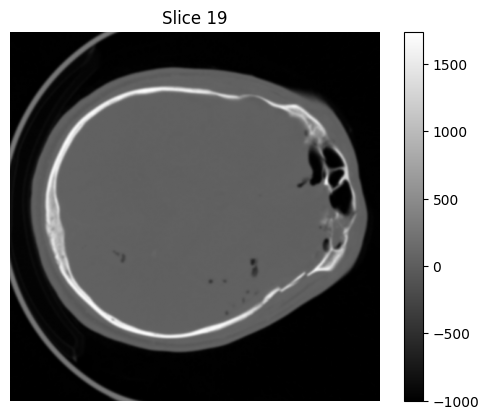

In [23]:
slice_index = data.shape[2] // 2

plt.imshow(data[:, :, slice_index], cmap="gray")
plt.title(f"Slice {slice_index}")
plt.colorbar()
plt.axis("off")
plt.show()

In [24]:
HEADER_PATH = "/home/thanh/Dataset_Ana/data/headers.csv"
df = pd.read_csv(HEADER_PATH)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 44 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   patient_id      75 non-null     int64  
 1   sizeof_hdr      75 non-null     int64  
 2   data_type       0 non-null      float64
 3   db_name         0 non-null      float64
 4   extents         75 non-null     int64  
 5   session_error   75 non-null     int64  
 6   regular         75 non-null     str    
 7   dim_info        75 non-null     int64  
 8   dim             75 non-null     str    
 9   intent_p1       75 non-null     float64
 10  intent_p2       75 non-null     float64
 11  intent_p3       75 non-null     float64
 12  intent_code     75 non-null     int64  
 13  datatype        75 non-null     int64  
 14  bitpix          75 non-null     int64  
 15  slice_start     75 non-null     int64  
 16  pixdim          75 non-null     str    
 17  vox_offset      75 non-null     float64
 18  scl

### Header explain
#### Header keys
---
- sizeof_hdr: size of header, always (348 bytes)
- magic:
    - n+1: single .nii (header + data)
    - ni1: double file (.hdr + .img)
- data_tpye: list data tpye
- db_name: name of old database
- extents: size of old file
- session_error:
- regular: 

#### Image Dimension
---
- dim_info:
- dim: dimension of
- intent_1,  intent_2, intent_3
- intent_code
- datatype: voxel's data type
- bitpix: bit/voxel
- slice_start: First slice index
- pixdim: voxel spacing
- vox_offset: 
- scl_slope, scl_inter: scaling
- slic_code:
- xyzt_units:
- cal_max, cal_min: display range
- slice_duration: slice timing
- toffset: time offset
- glmax, glmin: global max/min
- descrip: description
- aux_file: auxiliary file

#### Spatial Transformation
---
- qform_code, sform_code: transform code
    - 0 = uknown
    - 1 = Scanner Anat
    - 2 = Aligned Anat
    - 3 = Talairach
    - 4 = MNI152
- quatern_b, quatern_c, quatern_d: quaternion params
- qoffset_x, qoffset_y, qoffset_z: quaternion offset
- srow_x, srow_y, srow_z: 4×4 affine matrix rows
- intent_name: intent description text

In [25]:
df.nunique()

patient_id        75
sizeof_hdr         1
data_type          0
db_name            0
extents            1
session_error      1
regular            1
dim_info           1
dim               19
intent_p1          1
intent_p2          1
intent_p3          1
intent_code        1
datatype           1
bitpix             1
slice_start        1
pixdim            35
vox_offset         1
scl_slope          0
scl_inter          0
slice_end          1
slice_code         1
xyzt_units         1
cal_max            1
cal_min            1
slice_duration     1
toffset            1
glmax             63
glmin              9
descrip            1
aux_file           3
qform_code         1
sform_code         1
quatern_b          1
quatern_c          2
quatern_d          2
qoffset_x         36
qoffset_y         75
qoffset_z         68
srow_x            36
srow_y            75
srow_z            68
intent_name        0
magic              1
dtype: int64

In [26]:
drop_cols =['sizeof_hdr', 'data_type','db_name', 'extents', 'session_error', 'regular', 'dim_info', 'intent_p1', 'intent_p2', 'intent_p3', 'intent_code', 'datatype', 'bitpix', 'slice_start', 'vox_offset', 'scl_slope', 'scl_inter', 'slice_end', 'slice_code', 'xyzt_units', 'cal_max', 'cal_min', 'slice_duration', 'toffset', 'descrip', 'qform_code', 'sform_code', 'intent_name', 'magic']
df_drop = df.drop(columns=drop_cols)
df_drop.head()

,patient_id,dim,pixdim,glmax,glmin,aux_file,quatern_b,quatern_c,quatern_d,qoffset_x,qoffset_y,qoffset_z,srow_x,srow_y,srow_z
0,49,"[3, 512, 512, 39, 1, 1, 1, 1]","[-1.0, 0.412109375, 0.412109375, 5.0, 0.0, 0.0...",2914,-1024,;SIEMENS;Head_SAFIRE,-0.0,1.0,-0.0,105.293945,23.706055,-690.5,"[-0.412109375, -0.0, 0.0, 105.2939453125]","[-0.0, 0.412109375, 0.0, 23.7060546875]","[0.0, -0.0, 5.0, -690.5]"
1,50,"[3, 512, 512, 32, 1, 1, 1, 1]","[-1.0, 0.3515625, 0.3515625, 5.0, 0.0, 0.0, 0....",1943,-1021,;SIEMENS;Head_SAFIRE,-0.0,1.0,-0.0,89.824219,31.675781,-739.0,"[-0.3515625, -0.0, 0.0, 89.82421875]","[-0.0, 0.3515625, 0.0, 31.67578125]","[0.0, -0.0, 5.0, -739.0]"
2,51,"[3, 512, 512, 46, 1, 1, 1, 1]","[-1.0, 0.412109375, 0.412109375, 5.0, 0.0, 0.0...",3046,-1014,;SIEMENS;Head_SAFIRE,-0.0,1.0,-0.0,105.293945,26.706055,-740.0,"[-0.412109375, -0.0, 0.0, 105.2939453125]","[-0.0, 0.412109375, 0.0, 26.7060546875]","[0.0, -0.0, 5.0, -740.0]"
3,52,"[3, 512, 512, 35, 1, 1, 1, 1]","[-1.0, 0.390625, 0.390625, 5.0, 0.0, 0.0, 0.0,...",3071,-1018,;SIEMENS;Head_SAFIRE,-0.0,1.0,-0.0,99.804688,77.195312,-464.5,"[-0.390625, -0.0, 0.0, 99.8046875]","[-0.0, 0.390625, 0.0, 77.1953125]","[0.0, -0.0, 5.0, -464.5]"
4,53,"[3, 512, 512, 35, 1, 1, 1, 1]","[-1.0, 0.47265625, 0.47265625, 5.0, 0.0, 0.0, ...",2806,-1024,;SIEMENS;HeadRoutine,-0.0,1.0,-0.0,120.763672,47.236328,-512.5,"[-0.47265625, -0.0, 0.0, 120.763671875]","[-0.0, 0.47265625, 0.0, 47.236328125]","[0.0, -0.0, 5.0, -512.5]"


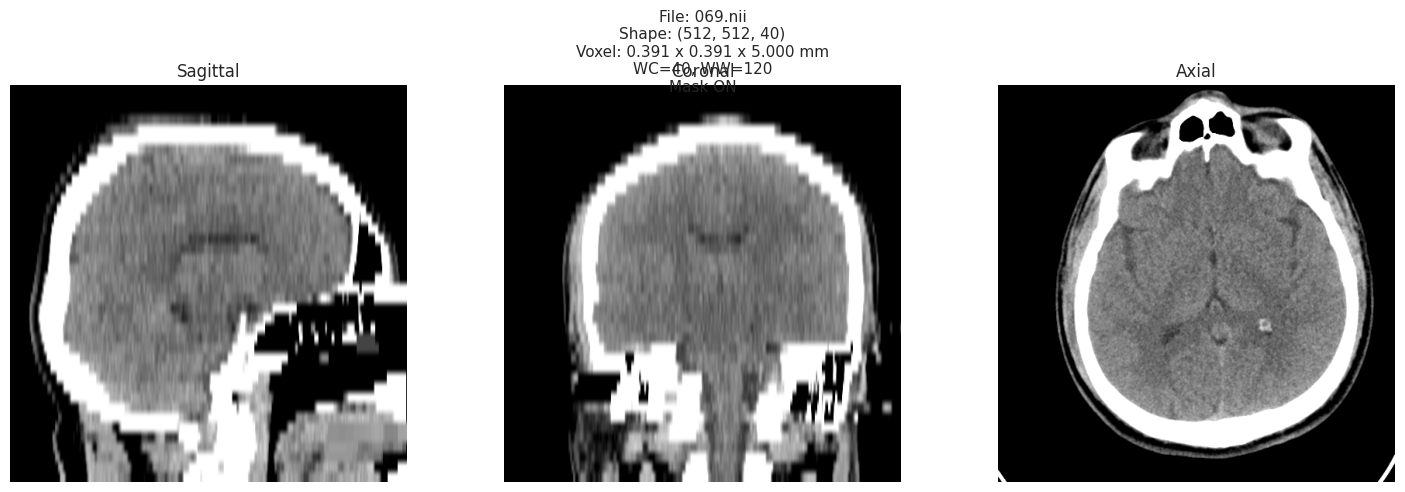

In [41]:
view_single('69', (40, 120), overlay=True)

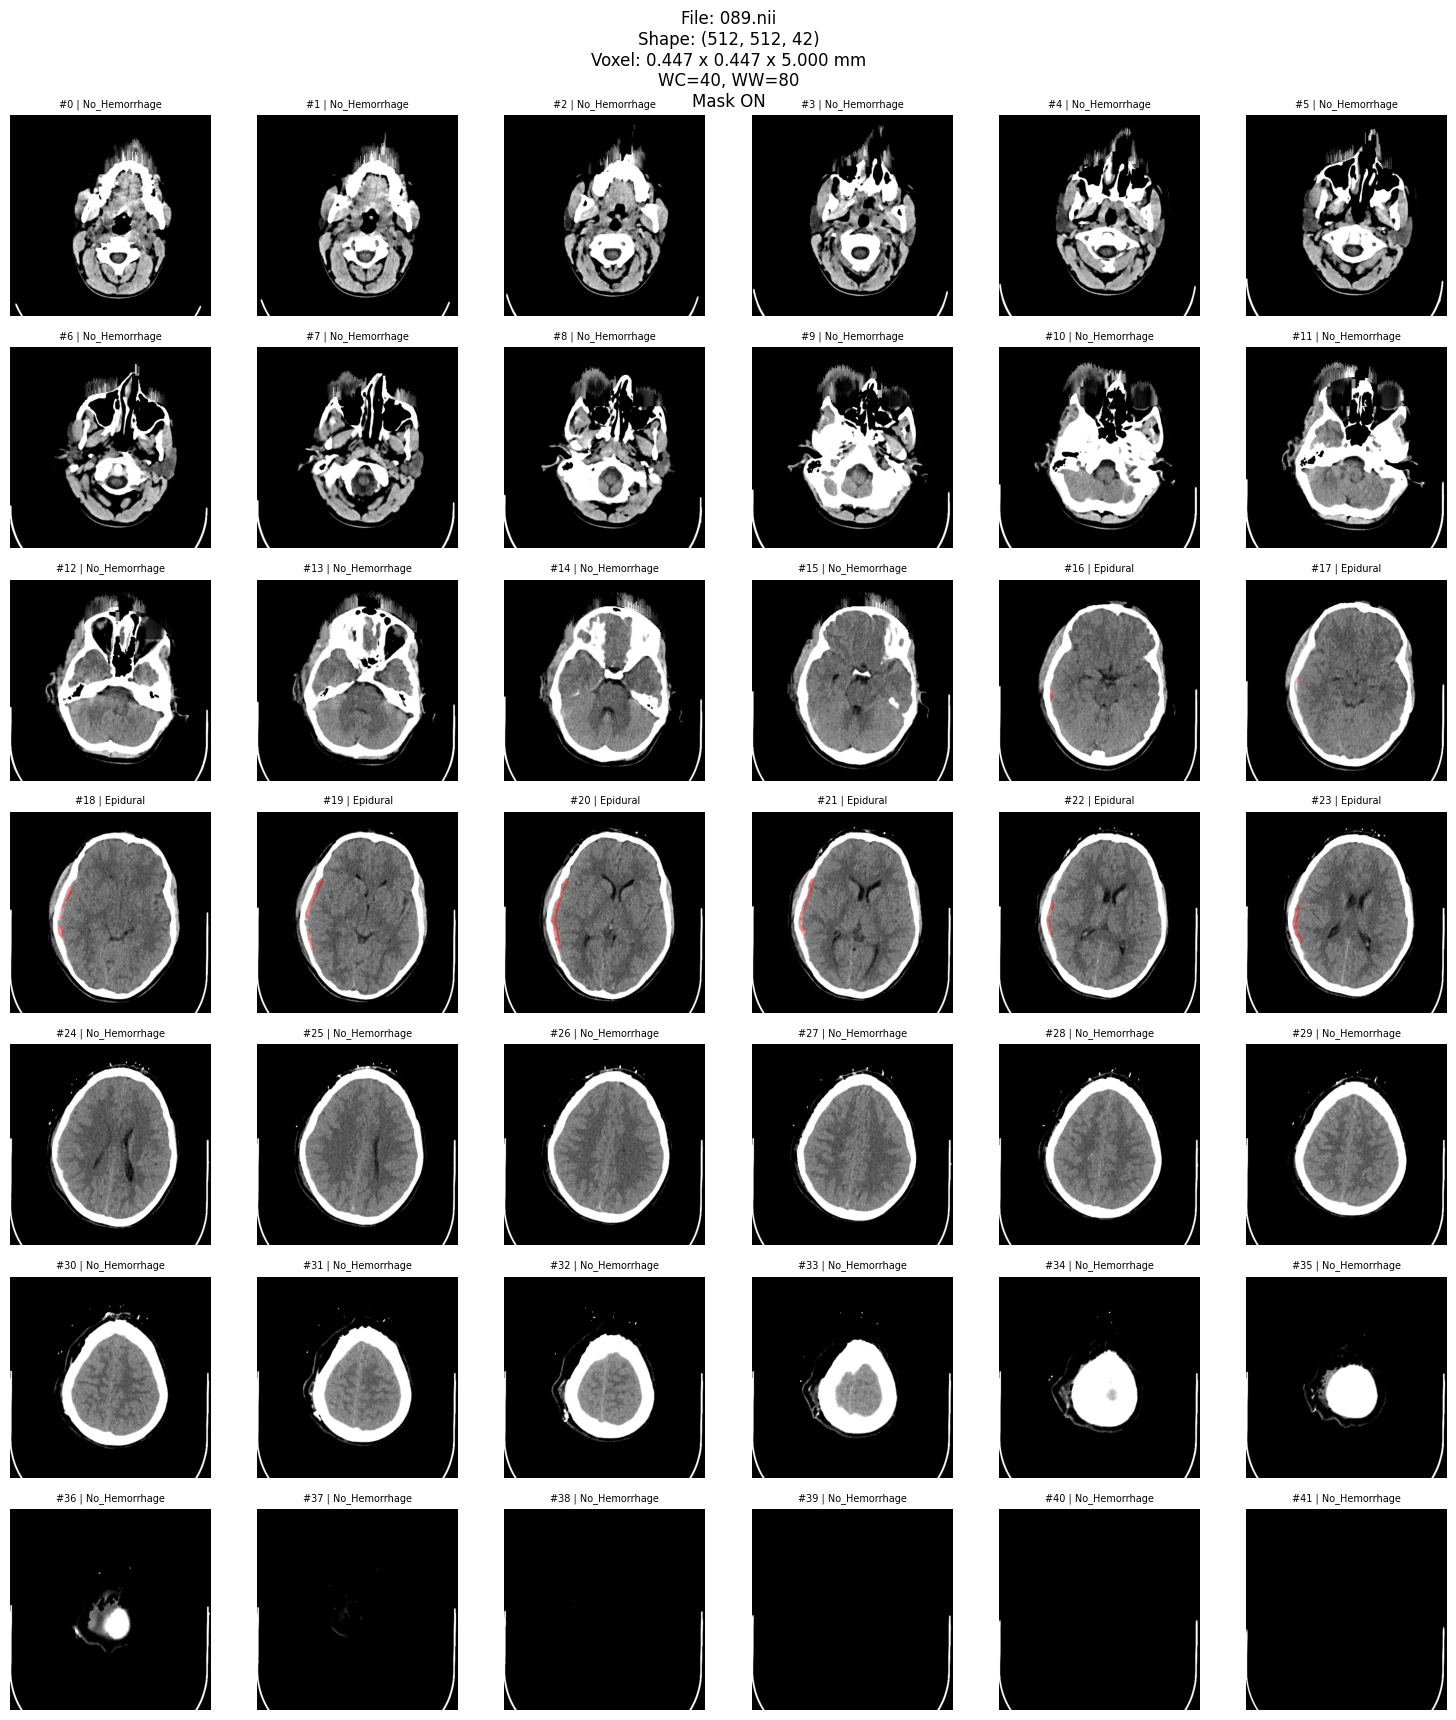

In [28]:
view_all("89", (40, 80), overlay=True)

Text(0.5, 1.0, 'Distribution of Slices per Scan')

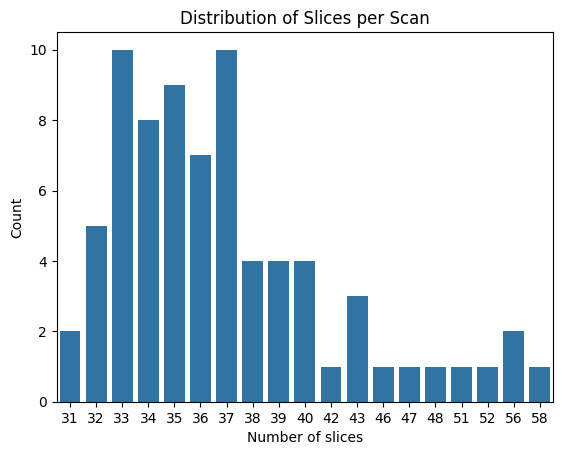

In [29]:
num_slices = df_drop['dim'].apply(ast.literal_eval).apply(lambda x: x[3]).value_counts().sort_index()

plt.figure()
sns.barplot(
    x=num_slices.index,
    y=num_slices.values
)

plt.xlabel("Number of slices")
plt.ylabel("Count")
plt.title("Distribution of Slices per Scan")

In [30]:
df_label = pd.read_csv(os.path.join(DATASET_DIR, LABEL_FILE_NAME))
check = df_label.groupby('PatientNumber')['SliceNumber'].apply(
    lambda x: sorted(x) == list(range(min(x), max(x)+1))
)
check.value_counts()

SliceNumber
True    75
Name: count, dtype: int64

##### No patient have missing slices

In [31]:
subtypes = [
    "Intraventricular",
    "Intraparenchymal",
    "Subarachnoid",
    "Epidural",
    "Subdural"
]

df_long = df_label.melt(
    id_vars=["PatientNumber", "SliceNumber"],
    value_vars=subtypes,
    var_name="Subtype",
    value_name="Presence"
)

# Chỉ giữ slice có hemorrhage subtype
df_long = df_long[df_long["Presence"] == 1]

In [32]:
df_label["SlicePercent"] = (
    df_label["SliceNumber"] /
    df_label.groupby("PatientNumber")["SliceNumber"].transform("max")
)

In [33]:
subtypes = [
    "Intraventricular",
    "Intraparenchymal",
    "Subarachnoid",
    "Epidural",
    "Subdural"
]

df_long = df_label.melt(
    id_vars=["PatientNumber", "SliceNumber", "SlicePercent"],
    value_vars=subtypes,
    var_name="Subtype",
    value_name="Presence"
)

df_long = df_long[df_long["Presence"] == 1]

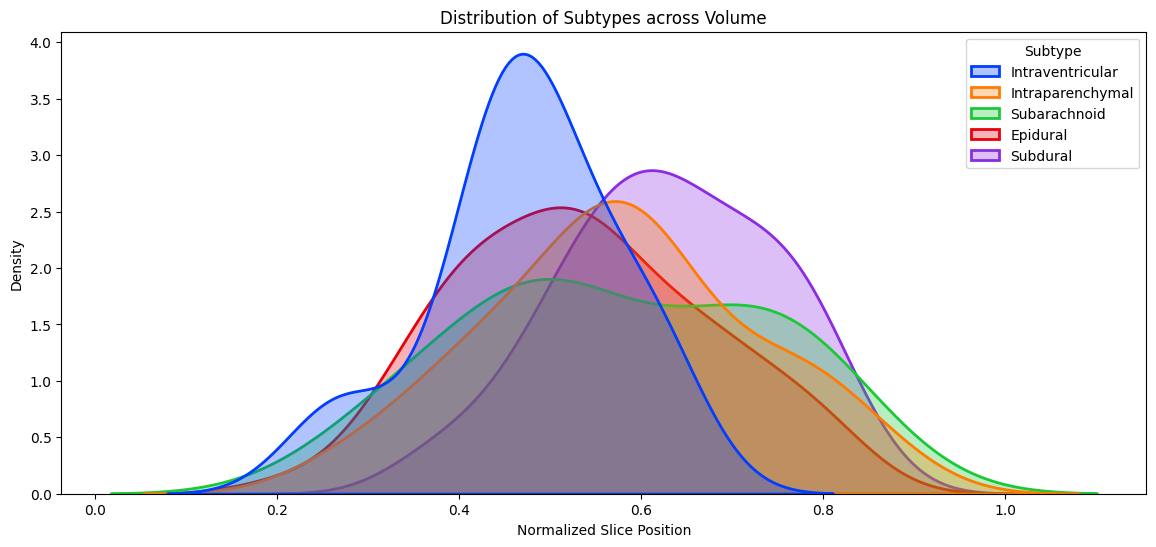

In [34]:
plt.figure(figsize=(14,6))

sns.kdeplot(
    data=df_long,
    x="SlicePercent",
    hue="Subtype",
    fill=True,
    common_norm=False,
    palette="bright",
    alpha=0.3,
    linewidth=2
)

plt.xlabel("Normalized Slice Position")
plt.title("Distribution of Subtypes across Volume")

plt.show()

In [35]:
df_long.head()

,PatientNumber,SliceNumber,SlicePercent,Subtype,Presence
921,80,8,0.242424,Intraventricular,1
922,80,9,0.272727,Intraventricular,1
923,80,10,0.303030,Intraventricular,1
927,80,14,0.424242,Intraventricular,1
928,80,15,0.454545,Intraventricular,1


In [36]:
mask_path = get_file_path("077.nii", subfolder="masks")
mask_data, zooms = load_nifti(mask_path)

_, vol_ml = cal_mask_volume(mask_data, zooms)

print("Volume: ", vol_ml, "(ml)")

Volume:  24.71502685546875 (ml)


In [37]:
df_long.head()

,PatientNumber,SliceNumber,SlicePercent,Subtype,Presence
921,80,8,0.242424,Intraventricular,1
922,80,9,0.272727,Intraventricular,1
923,80,10,0.303030,Intraventricular,1
927,80,14,0.424242,Intraventricular,1
928,80,15,0.454545,Intraventricular,1


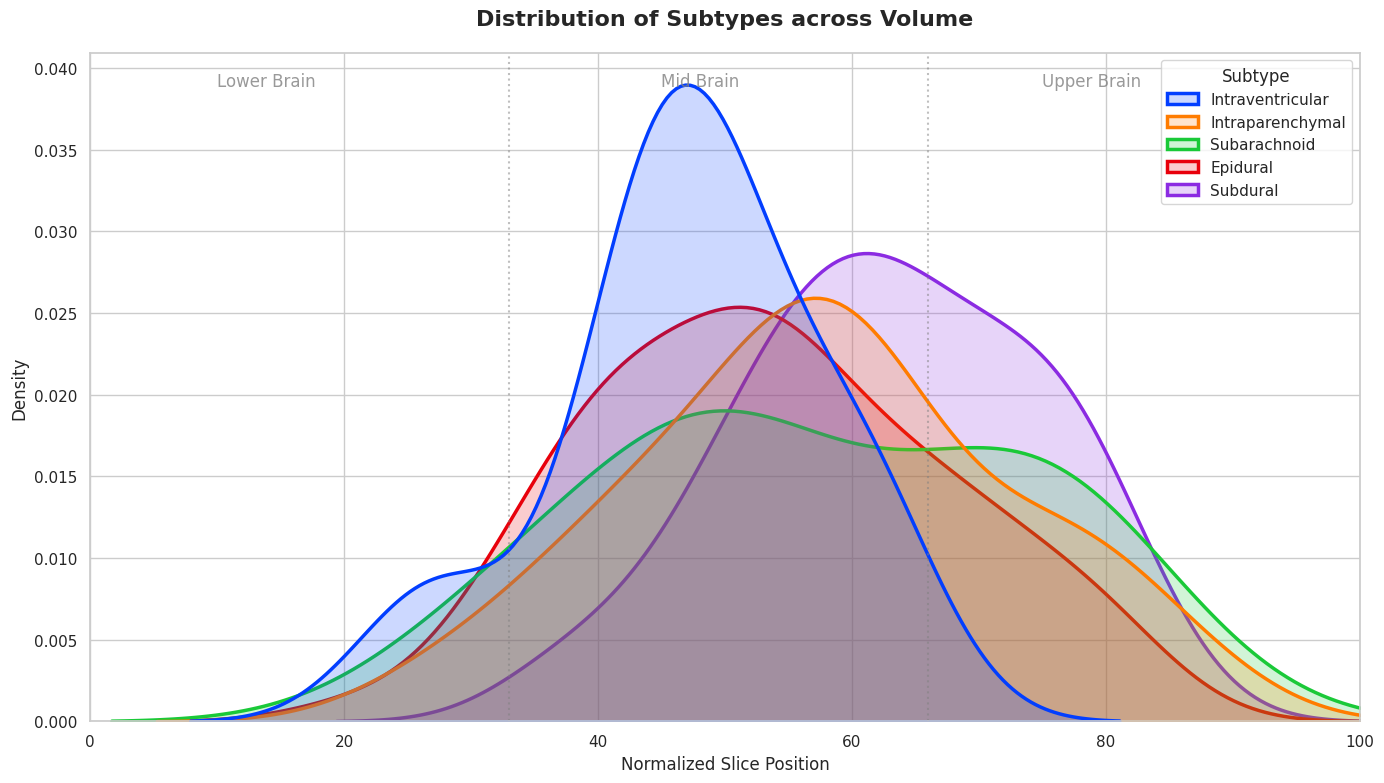

/tmp/ipykernel_11979/4066695566.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


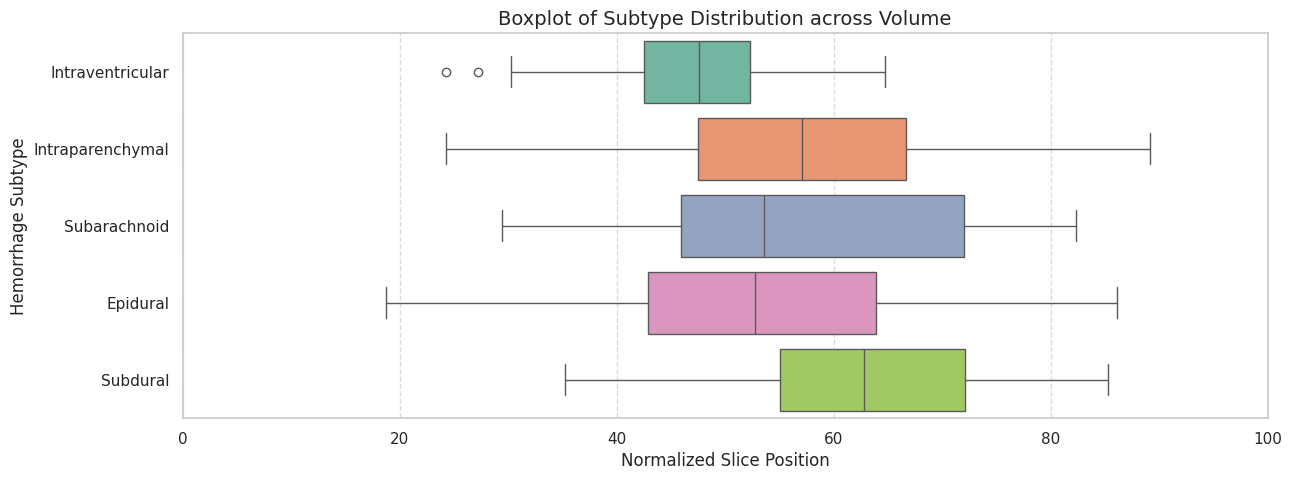

In [38]:
df_present = df_long[df_long["Presence"] == 1].copy()

if df_present["SlicePercent"].max() <= 1.0:
    df_present["SlicePercent_100"] = df_present["SlicePercent"] * 100
else:
    df_present["SlicePercent_100"] = df_present["SlicePercent"]

sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 8))

ax = sns.kdeplot(
    data=df_present,
    x="SlicePercent_100",
    hue="Subtype",
    common_norm=False,
    fill=True,
    alpha=0.2,
    linewidth=2.5,
    palette="bright"
)

plt.title("Distribution of Subtypes across Volume", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Normalized Slice Position", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.xlim(0, 100)

plt.axvline(33, color='gray', linestyle=':', alpha=0.5)
plt.axvline(66, color='gray', linestyle=':', alpha=0.5)
plt.text(10, plt.ylim()[1]*0.95, "Lower Brain", color='gray', alpha=0.8)
plt.text(45, plt.ylim()[1]*0.95, "Mid Brain", color='gray', alpha=0.8)
plt.text(75, plt.ylim()[1]*0.95, "Upper Brain", color='gray', alpha=0.8)

plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
sns.boxplot(
    data=df_present, 
    x="SlicePercent_100", 
    y="Subtype", 
    palette="Set2",
    whis=1.5 
)

plt.title("Boxplot of Subtype Distribution across Volume", fontsize=14)
plt.xlabel("Normalized Slice Position")
plt.ylabel("Hemorrhage Subtype")
plt.xlim(0, 100)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [39]:
df_filtered = df_volume[df_volume["MaskVolume_ml"] > 0]

sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 6))

ax = sns.histplot(df_filtered["MaskVolume_ml"], kde=False, color="salmon", bins=100)

plt.title("Distribution of Positive Hemorrhage Volume per Patient", fontsize=16, fontweight='bold')
plt.xlabel("Volume (ml)", fontsize=12)
plt.ylabel("Count", fontsize=12)


NameError: name 'df_volume' is not defined